# 05 — PCA representation and clustering

**Notebook 5 of 9 — Drosophila book-chapter production pipeline**

**Purpose:** Fit the production PCA representation and derive PCA-Ward and PCA-KMeans assignments at k = 2 and k = 3.

**Primary inputs:** `data/processed/drosophila_features_reduced.csv`

**Primary outputs:** `data/processed/k2_cluster_assignments_pca.csv`; `data/processed/k3_cluster_assignments_pca.csv`

**Manuscript role:** PCA dimensionality reduction and clustering; supplies PH and PK streams for the complete six-stream audits and stability-qualified consensus analyses.

**Project authors:** Tim Rogalsky, Nicolas Malagon, Lia Campbell-Enns, Matthaeus Dyck

**Reproducibility:** Designed for fresh-kernel execution in production order 01→09 using repository-relative paths. It consumes the explicit 45-feature interface written by Notebook 04 and requires no private, diagnostic, or obsolete provenance artifact.

The production representation uses the first 12 components from one PCA fit to the standardized 108 × 45 feature matrix and explains 86.8434% of cumulative variance. Clusters are computational partitions rather than biological cell types.

## Setup and production input

PCA is fit to the standardized 45-feature table. Repository-relative paths are used throughout, and the input is checked before analysis.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, rand_score
from sklearn.preprocessing import StandardScaler

INPUT_PATH = Path("data/processed/drosophila_features_reduced.csv")
K2_ASSIGNMENT_PATH = Path("data/processed/k2_cluster_assignments_pca.csv")
K3_ASSIGNMENT_PATH = Path("data/processed/k3_cluster_assignments_pca.csv")
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

n_pcs_to_use = 12
PC_DIMENSIONS = (12, 13, 14)
EXPECTED_CUMULATIVE_VARIANCE = {12: 0.868434, 13: 0.887382, 14: 0.903394}

features = pd.read_csv(INPUT_PATH, index_col=0)
features.index = features.index.astype(str)
features.index.name = "Cell_Name"
cell_names = features.index.tolist()
duplicate_column_count = int(features.columns.duplicated().sum())
non_finite_count = int((~np.isfinite(features.to_numpy(dtype=float))).sum())

assert features.shape == (108, 45), f"Unexpected input shape: {features.shape}"
assert features.index.is_unique, "Cell_Name values must be unique."
assert duplicate_column_count == 0, "Duplicate feature columns detected."
assert non_finite_count == 0, "Non-finite feature values detected."
assert len(cell_names) == 108 and pd.Index(cell_names).is_unique
assert features.index.astype(str).tolist() == cell_names, "Input cell order was not preserved."

# Fit the scaler once and PCA once; every retained dimensionality uses leading columns
# from this single fitted PCA score matrix.
scaler = StandardScaler()
X_standardized = scaler.fit_transform(features)
assert X_standardized.shape == (108, 45)
assert np.isfinite(X_standardized).all()
pca = PCA()
X_pca = pca.fit_transform(X_standardized)
assert X_pca.shape == (108, 45)
assert np.isfinite(X_pca).all()
pc_columns = [f"PC{i}" for i in range(1, X_pca.shape[1] + 1)]
pc_df = pd.DataFrame(X_pca, index=features.index, columns=pc_columns)
cum_var = np.cumsum(pca.explained_variance_ratio_)
score_matrices = {n: X_pca[:, :n] for n in PC_DIMENSIONS}
X_pca_12 = score_matrices[12]
X_pca_13 = score_matrices[13]
X_pca_14 = score_matrices[14]
data_for_clust = X_pca_12

for n_pcs, scores in score_matrices.items():
    assert scores.shape == (108, n_pcs)
    assert np.isfinite(scores).all()
    assert np.isclose(
        cum_var[n_pcs - 1], EXPECTED_CUMULATIVE_VARIANCE[n_pcs], rtol=0.0, atol=5e-7
    ), f"Unexpected cumulative explained variance at {n_pcs} PCs."

print(f"Input: {INPUT_PATH} | shape={features.shape}")
print(f"Duplicate columns: {duplicate_column_count} | non-finite values: {non_finite_count}")
print(f"Unique Cell_Name values: {pd.Index(cell_names).nunique()}")
print(f"Standardized matrix shape: {X_standardized.shape}; PCA score matrix shape: {X_pca.shape}")
print("Cumulative explained variance: " + ", ".join(
    f"{n} PCs={cum_var[n - 1]:.4%}" for n in PC_DIMENSIONS
))

Input: data\processed\drosophila_features_reduced.csv | shape=(108, 45)
Duplicate columns: 0 | non-finite values: 0
Unique Cell_Name values: 108
Standardized matrix shape: (108, 45); PCA score matrix shape: (108, 45)
Cumulative explained variance: 12 PCs=86.8434%, 13 PCs=88.7382%, 14 PCs=90.3394%


## PCA representation and loadings

The 12-PC representation explains approximately 86.8% of variance in the standardized production feature table. Loadings below identify strong contributors to each retained component; they are descriptive associations, not causal biological effects.

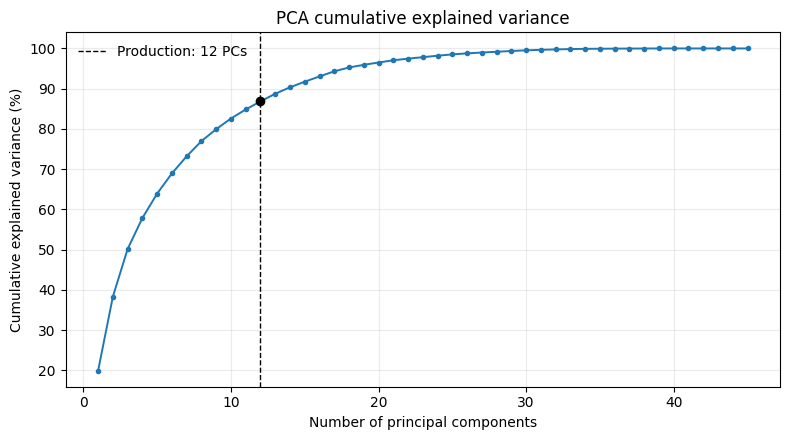

Feature,a_median,a_skew,b_band_power_low,b_dominant_freq,b_spectral_entropy,c_avg_time_between_peaks,c_mean_peak_to_trough_time,c_mean_trough_to_peak_time,c_std_time_between_peaks,d_final_magnitude,...,d_poly_peak_c3,d_poly_trough_c0,e_autocorr_lag1,e_autocorr_lagk,e_hurst_exponent,f_delta_mean,f_early_mean,f_late_autocorr,f_late_mean,g_asymmetry_index
PC,,,,,,,,,,,,,,,,,,,,,
PC1,,,,,,,,,,,...,,,,,,,,,,
PC10,0.645172,-0.478319,-0.258177,,,,,,,,...,,,,,,,,,,
PC11,0.282502,,0.794832,,,,,,,,...,,,,,0.259987,,,,,
PC12,,,,0.374918,,,,,0.341579,,...,,,,,0.400985,,,,,
PC2,,,,,,,,,,,...,,-0.294875,,,,,,,,
PC3,,,,,0.308987,0.305169,,,,,...,,,0.350754,,,,,,,
PC4,,,,,,0.318787,0.313499,,0.292208,,...,,,,,,,,,,
PC5,,,,,,,,,,,...,,,,,,0.445747,-0.324648,,0.326402,
PC6,,,,,,,,,,0.36314,...,,,,,,,,-0.348756,,


In [2]:
fig, ax = plt.subplots(figsize=(8, 4.5))
component_numbers = np.arange(1, len(cum_var) + 1)
ax.plot(component_numbers, 100 * cum_var, marker="o", markersize=3, linewidth=1.4)
ax.axvline(n_pcs_to_use, color="black", linestyle="--", linewidth=1, label="Production: 12 PCs")
ax.scatter([n_pcs_to_use], [100 * cum_var[n_pcs_to_use - 1]], color="black", zorder=3)
ax.set(xlabel="Number of principal components", ylabel="Cumulative explained variance (%)",
       title="PCA cumulative explained variance")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "pca_cumulative_explained_variance.png", dpi=300, bbox_inches="tight")
plt.show()

loadings = pd.DataFrame(pca.components_.T, index=features.columns, columns=pc_columns)
top_loading_rows = []
for pc in pc_columns[:n_pcs_to_use]:
    for feature_name in loadings[pc].abs().nlargest(3).index:
        top_loading_rows.append({"PC": pc, "Feature": feature_name, "Loading": loadings.loc[feature_name, pc]})
top_loadings = pd.DataFrame(top_loading_rows)
display(top_loadings.pivot(index="PC", columns="Feature", values="Loading").fillna(""))

## KMeans cluster-number diagnostic

The inertia display is a descriptive notebook diagnostic for `k = 1...10`, using KMeans with `random_state=0` and `n_init="auto"`. Its second-difference marker at k = 3 does not determine the chapter's primary clustering resolution or establish k = 3 as uniquely optimal. The primary coarse k = 2 and secondary finer k = 3 resolutions serve different analytical purposes without changing the 12-PC representation.

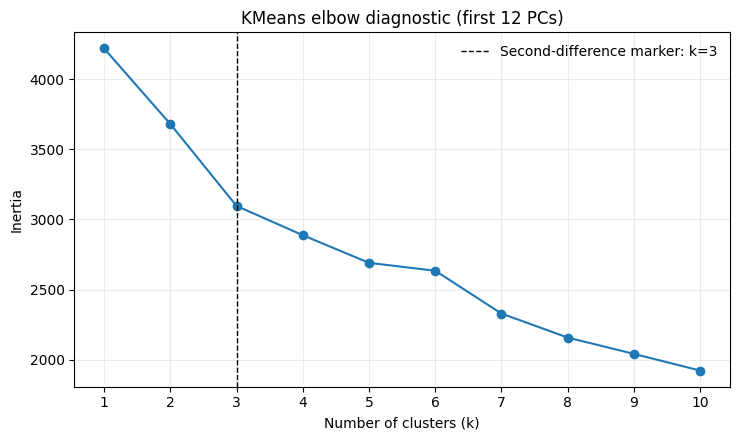

Second-difference diagnostic marker: k=3


In [3]:
ks = list(range(1, 11))
inertias = []
for k in ks:
    model = KMeans(n_clusters=k, random_state=0, n_init="auto")
    model.fit(data_for_clust)
    inertias.append(model.inertia_)

second_differences = np.diff(np.diff(inertias))
elbow_k = ks[int(np.argmax(second_differences)) + 1]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(ks, inertias, marker="o")
ax.axvline(elbow_k, color="black", linestyle="--", linewidth=1, label=f"Second-difference marker: k={elbow_k}")
ax.set(xlabel="Number of clusters (k)", ylabel="Inertia", title="KMeans elbow diagnostic (first 12 PCs)")
ax.set_xticks(ks)
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "pca_kmeans_elbow.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Second-difference diagnostic marker: k={elbow_k}")

## Primary k=2 and secondary k=3 production clustering

**Primary coarse k = 2.** PCA-Ward (`K2_PH`) and PCA-KMeans (`K2_PK`) are computed on the 12-PC representation. `K2_PK` uses k-means++ initialization, 50 starts, and `random_state=42`. Their exported one-based sizes are 20/88 and 66/42, respectively, with RI = 0.631014, NMI = 0.227651, and ARI = 0.250161. `K2_PH` remains a valid production partition in the complete six-stream audit but is excluded from the strict five-stream consensus because its cut changes sharply across 12–14 PCs. Stable multi-start `K2_PK` is the retained PCA stream there.

**Secondary finer k = 3.** The 12-PC PCA-Ward (`K3_PH`) and PCA-KMeans (`K3_PK`) assignments have exported one-based sizes 20/32/56 and 59/20/29. `K3_PK` uses k-means++ initialization, `n_init="auto"`, and `random_state=0`. Their agreement is RI = 0.642264 and NMI = 0.358732. `K3_PH` remains a valid production partition in the complete six-stream audit, but its material sensitivity across 12–14 PCs excludes it from the stability-qualified strict five-stream set. KMeans labels at both resolutions are normalized only by adding one to native scikit-learn indices; no agreement-based permutation is used.

In [4]:
# One 12-PC Ward hierarchy supplies both native one-based production cuts.
Z_12 = linkage(X_pca_12, method="ward")
K2_PH = fcluster(Z_12, t=2, criterion="maxclust").astype(int)
K3_PH = fcluster(Z_12, t=3, criterion="maxclust").astype(int)

# Validated primary coarse PCA-KMeans fit. Native 0/1 labels are normalized only by +1.
kmeans_k2 = KMeans(
    n_clusters=2, init="k-means++", n_init=50, random_state=42
)
K2_PK_raw = kmeans_k2.fit_predict(X_pca_12)
K2_PK = K2_PK_raw + 1

# Preserve the established secondary k=3 estimator and normalize only by +1.
kmeans_k3 = KMeans(n_clusters=3, random_state=0, n_init="auto")
K3_PK_raw = kmeans_k3.fit_predict(X_pca_12)
K3_PK = K3_PK_raw + 1

assert {label: int(np.sum(K2_PH == label)) for label in (1, 2)} == {1: 20, 2: 88}
assert {label: int(np.sum(K2_PK_raw == label)) for label in (0, 1)} == {0: 66, 1: 42}
assert {label: int(np.sum(K2_PK == label)) for label in (1, 2)} == {1: 66, 2: 42}
assert np.isclose(kmeans_k2.inertia_, 3535.189727866968, rtol=1e-12, atol=1e-9)
assert {label: int(np.sum(K3_PH == label)) for label in (1, 2, 3)} == {1: 20, 2: 32, 3: 56}
assert {label: int(np.sum(K3_PK_raw == label)) for label in (0, 1, 2)} == {0: 59, 1: 20, 2: 29}
assert {label: int(np.sum(K3_PK == label)) for label in (1, 2, 3)} == {1: 59, 2: 20, 3: 29}

k2_contingency = pd.crosstab(
    pd.Series(K2_PH, name="K2_PH"), pd.Series(K2_PK, name="K2_PK")
).reindex(index=[1, 2], columns=[1, 2], fill_value=0)
expected_k2_contingency = np.asarray([[2, 18], [64, 24]])
assert np.array_equal(k2_contingency.to_numpy(), expected_k2_contingency)
k2_ri = rand_score(K2_PH, K2_PK)
k2_nmi = normalized_mutual_info_score(K2_PH, K2_PK)
k2_ari = adjusted_rand_score(K2_PH, K2_PK)
assert np.isclose(k2_ri, 0.631014, rtol=0.0, atol=5e-7)
assert np.isclose(k2_nmi, 0.227651, rtol=0.0, atol=5e-7)
assert np.isclose(k2_ari, 0.250161, rtol=0.0, atol=5e-7)

k3_contingency = pd.crosstab(
    pd.Series(K3_PH, name="K3_PH"), pd.Series(K3_PK, name="K3_PK")
)
k3_ri = rand_score(K3_PH, K3_PK)
k3_nmi = normalized_mutual_info_score(K3_PH, K3_PK)
assert np.isclose(k3_ri, 0.642264, rtol=0.0, atol=5e-7)
assert np.isclose(k3_nmi, 0.358732, rtol=0.0, atol=5e-7)

# Backward-compatible plotting aliases only; all displayed labels are one-based.
Z = Z_12
cluster_km = K3_PK
cluster_hc = K3_PH

print("Primary k=2 PH versus PK contingency:")
display(k2_contingency)
print(f"K2_PH sizes: {{1: 20, 2: 88}}")
print(f"K2_PK raw sizes: {{0: 66, 1: 42}}; exported sizes: {{1: 66, 2: 42}}")
print(f"K2_PK inertia: {kmeans_k2.inertia_:.12f}")
print(f"K2 PH vs PK: RI={k2_ri:.15f}; NMI={k2_nmi:.15f}; ARI={k2_ari:.15f}")
print(f"K3_PH sizes: {{1: 20, 2: 32, 3: 56}}")
print(f"K3_PK raw sizes: {{0: 59, 1: 20, 2: 29}}; exported sizes: {{1: 59, 2: 20, 3: 29}}")
print(f"K3 PH vs PK: RI={k3_ri:.15f}; NMI={k3_nmi:.15f}")

Primary k=2 PH versus PK contingency:


K2_PK,1,2
K2_PH,,
1,2,18
2,64,24


K2_PH sizes: {1: 20, 2: 88}
K2_PK raw sizes: {0: 66, 1: 42}; exported sizes: {1: 66, 2: 42}
K2_PK inertia: 3535.189727866969
K2 PH vs PK: RI=0.631014191761855; NMI=0.227651120344305; ARI=0.250161062001201
K3_PH sizes: {1: 20, 2: 32, 3: 56}
K3_PK raw sizes: {0: 59, 1: 20, 2: 29}; exported sizes: {1: 59, 2: 20, 3: 29}
K3 PH vs PK: RI=0.642263759086189; NMI=0.358732291281863


### PC1/PC2 projections and Ward hierarchy at both production resolutions

These score panels project the cells onto PC1 and PC2 for visualization only; clustering uses all 12 retained PCs. The k=2 panels show the primary coarse resolution, and the k=3 panels show the secondary finer resolution. `K2_PH` and `K3_PH` remain visible because each belongs in its complete six-stream audit, although dimensionality sensitivity excludes both from the corresponding stability-qualified strict analyses. The dendrogram panels then show the same 12-PC Ward hierarchy viewed at the two corresponding cuts.

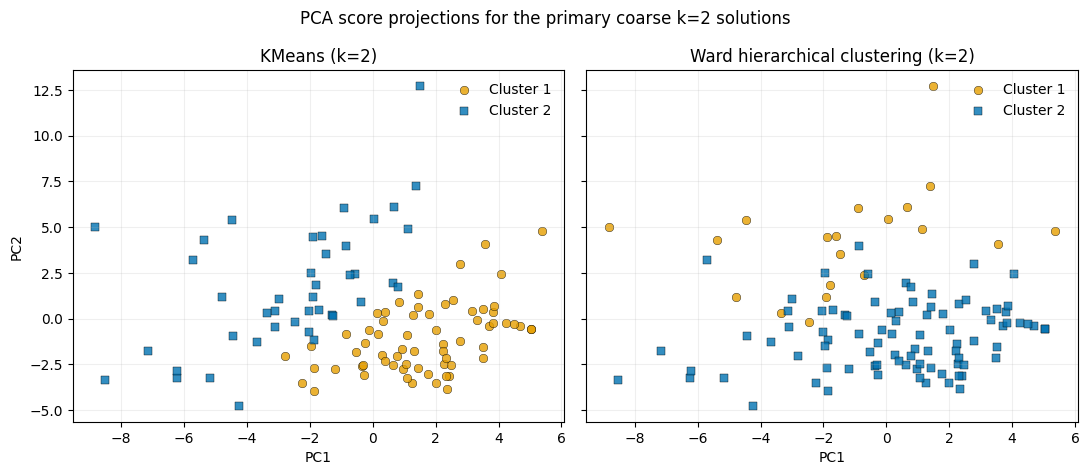

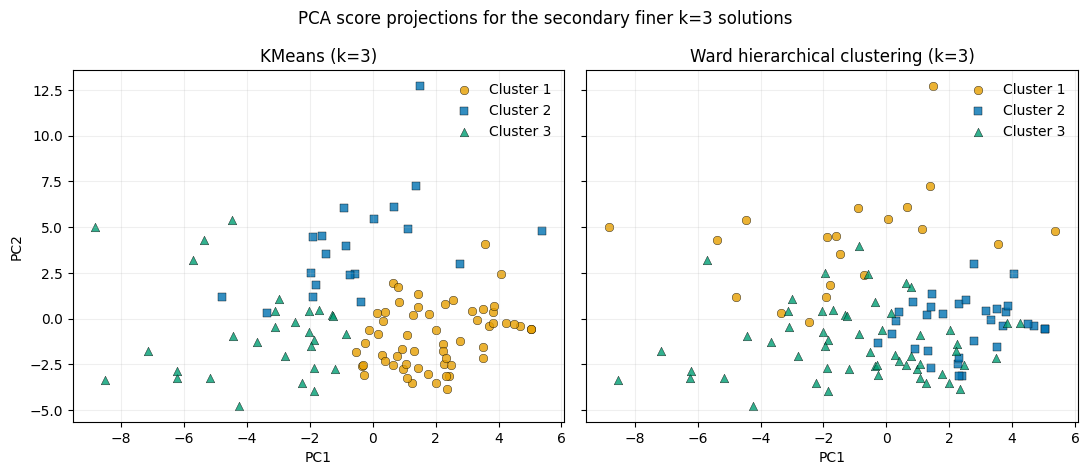

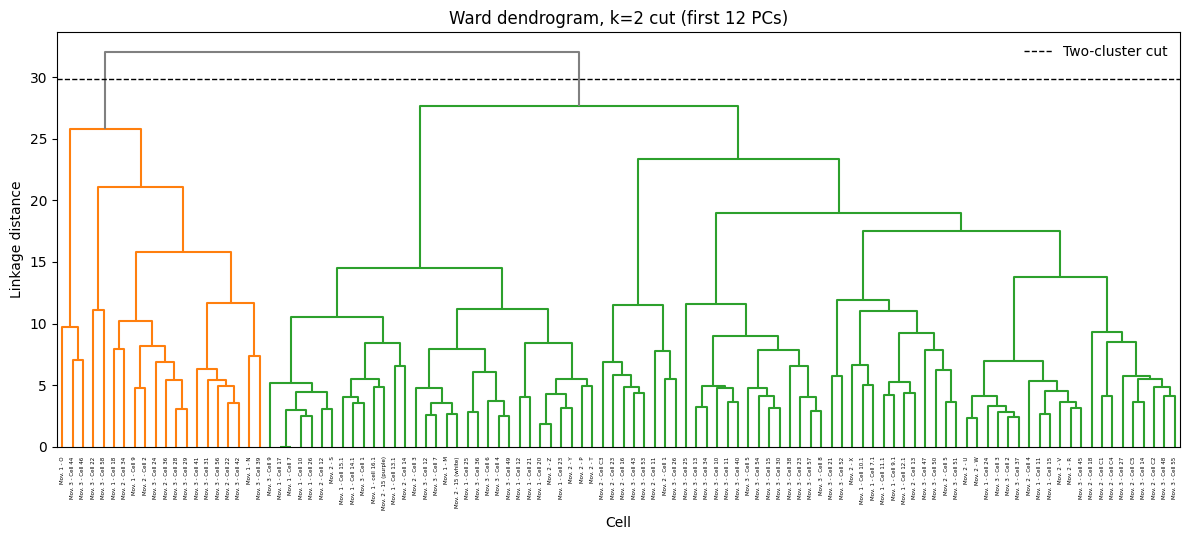

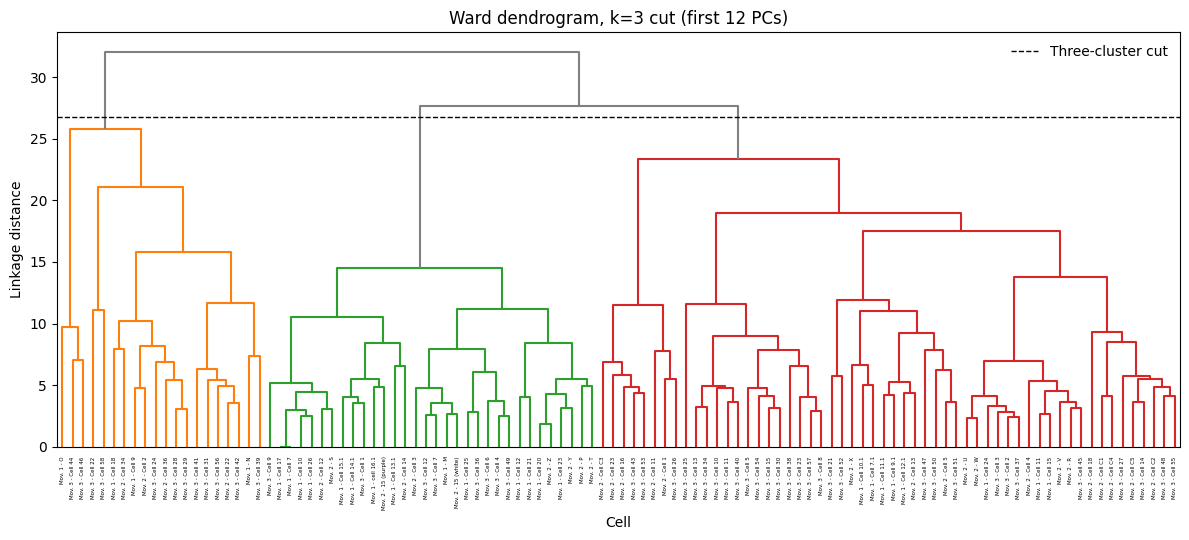

Visual Ward cut heights: k=2 29.855586089707; k=3 26.734116370565
Distance-cut parity with production Ward labels: k=2 ARI=1.0; k=3 ARI=1.0


In [5]:
cluster_color_map = {1: "#E69F00", 2: "#0072B2", 3: "#009E73"}
cluster_marker_map = {1: "o", 2: "s", 3: "^"}

def plot_score_projection(left_labels, right_labels, left_title, right_title, suptitle, output_path):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharex=True, sharey=True)
    for ax, labels, title in [
        (axes[0], left_labels, left_title),
        (axes[1], right_labels, right_title),
    ]:
        for label in np.unique(labels):
            mask = labels == label
            ax.scatter(pc_df.loc[mask, "PC1"], pc_df.loc[mask, "PC2"],
                       marker=cluster_marker_map[int(label)], color=cluster_color_map[int(label)],
                       edgecolor="black", linewidth=0.35, s=38, alpha=0.8,
                       label=f"Cluster {label}")
        ax.set(title=title, xlabel="PC1")
        ax.grid(alpha=0.2)
        ax.legend(frameon=False)
    axes[0].set_ylabel("PC2")
    fig.suptitle(suptitle)
    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

plot_score_projection(
    K2_PK, K2_PH, "KMeans (k=2)", "Ward hierarchical clustering (k=2)",
    "PCA score projections for the primary coarse k=2 solutions",
    FIGURE_DIR / "pca_hc2_vs_km2_scores.png",
)
plot_score_projection(
    K3_PK, K3_PH, "KMeans (k=3)", "Ward hierarchical clustering (k=3)",
    "PCA score projections for the secondary finer k=3 solutions",
    FIGURE_DIR / "pca_hc3_vs_km3_scores.png",
)

# Midpoint thresholds lie strictly between the relevant Ward merge heights.
k2_cut_height = (Z_12[-2, 2] + Z_12[-1, 2]) / 2
k3_cut_height = (Z_12[-3, 2] + Z_12[-2, 2]) / 2
k2_distance_cut = fcluster(Z_12, t=k2_cut_height, criterion="distance")
k3_distance_cut = fcluster(Z_12, t=k3_cut_height, criterion="distance")
k2_cut_ari = adjusted_rand_score(K2_PH, k2_distance_cut)
k3_cut_ari = adjusted_rand_score(K3_PH, k3_distance_cut)
assert np.isclose(k2_cut_ari, 1.0, rtol=0.0, atol=1e-12)
assert np.isclose(k3_cut_ari, 1.0, rtol=0.0, atol=1e-12)

def plot_ward_dendrogram(cut_height, cut_label, title, output_path):
    fig, ax = plt.subplots(figsize=(12, 5.5))
    dendrogram(Z_12, labels=pc_df.index.to_list(), leaf_rotation=90, leaf_font_size=4,
               color_threshold=cut_height, above_threshold_color="grey", ax=ax)
    ax.axhline(cut_height, color="black", linestyle="--", linewidth=1, label=cut_label)
    ax.set(title=title, xlabel="Cell", ylabel="Linkage distance")
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

plot_ward_dendrogram(
    k2_cut_height, "Two-cluster cut", "Ward dendrogram, k=2 cut (first 12 PCs)",
    FIGURE_DIR / "pca_ward_hc2_dendrogram.png",
)
plot_ward_dendrogram(
    k3_cut_height, "Three-cluster cut", "Ward dendrogram, k=3 cut (first 12 PCs)",
    FIGURE_DIR / "pca_ward_hc3_dendrogram.png",
)
print(f"Visual Ward cut heights: k=2 {k2_cut_height:.12f}; k=3 {k3_cut_height:.12f}")
print(f"Distance-cut parity with production Ward labels: k=2 ARI={k2_cut_ari:.1f}; k=3 ARI={k3_cut_ari:.1f}")

## k=2 PCA-dimensionality sensitivity check

This concise k=2 reproducibility check uses leading columns from the same single PCA fit; it is not a new model-selection procedure. As reflected in the primary k=2 visualization above, Ward changes sharply across the already justified 12–14-PC range, while validated multi-start KMeans remains highly stable. `K2_PH` is therefore audit-only in the later strict-consensus construction, while `K2_PK` is retained as the methodologically supported coarse PCA partition. The established 12-PC production representation itself was not chosen to maximize agreement.

In [6]:
dimension_pairs = ((12, 13), (12, 14), (13, 14))
sensitivity_ward = {12: K2_PH.copy()}
sensitivity_kmeans = {12: K2_PK.copy()}
sensitivity_kmeans_models = {12: kmeans_k2}

for n_pcs in (13, 14):
    scores = score_matrices[n_pcs]
    sensitivity_ward[n_pcs] = fcluster(
        linkage(scores, method="ward"), t=2, criterion="maxclust"
    ).astype(int)
    model = KMeans(
        n_clusters=2, init="k-means++", n_init=50, random_state=42
    )
    sensitivity_kmeans[n_pcs] = model.fit_predict(scores) + 1
    sensitivity_kmeans_models[n_pcs] = model

expected_ward_sizes = {12: (20, 88), 13: (47, 61), 14: (13, 95)}
expected_kmeans_sizes = {12: (42, 66), 13: (43, 65), 14: (42, 66)}
observed_ward_sizes = {
    n: tuple(sorted(np.unique(labels, return_counts=True)[1].tolist()))
    for n, labels in sensitivity_ward.items()
}
observed_kmeans_sizes = {
    n: tuple(sorted(np.unique(labels, return_counts=True)[1].tolist()))
    for n, labels in sensitivity_kmeans.items()
}
assert observed_ward_sizes == expected_ward_sizes
assert observed_kmeans_sizes == expected_kmeans_sizes

expected_ward_ari = {(12, 13): 0.046314, (12, 14): 0.684745, (13, 14): -0.001250}
expected_kmeans_ari = {(12, 13): 0.962914, (12, 14): 1.000000, (13, 14): 0.962914}
ward_dimension_ari = {
    pair: adjusted_rand_score(sensitivity_ward[pair[0]], sensitivity_ward[pair[1]])
    for pair in dimension_pairs
}
kmeans_dimension_ari = {
    pair: adjusted_rand_score(sensitivity_kmeans[pair[0]], sensitivity_kmeans[pair[1]])
    for pair in dimension_pairs
}
for pair in dimension_pairs:
    assert np.isclose(ward_dimension_ari[pair], expected_ward_ari[pair], rtol=0.0, atol=5e-7)
    assert np.isclose(kmeans_dimension_ari[pair], expected_kmeans_ari[pair], rtol=0.0, atol=5e-7)

variance_sensitivity = pd.DataFrame({
    "PCs": PC_DIMENSIONS,
    "Cumulative_Variance": [cum_var[n - 1] for n in PC_DIMENSIONS],
    "Ward_Sorted_Sizes": [observed_ward_sizes[n] for n in PC_DIMENSIONS],
    "KMeans_Sorted_Sizes": [observed_kmeans_sizes[n] for n in PC_DIMENSIONS],
})
dimensionality_sensitivity = pd.DataFrame([
    {
        "Comparison": f"{left} vs {right}",
        "Ward_ARI": ward_dimension_ari[(left, right)],
        "KMeans_ARI": kmeans_dimension_ari[(left, right)],
    }
    for left, right in dimension_pairs
])
variance_sensitivity_display = variance_sensitivity.copy()
variance_sensitivity_display["Cumulative_Variance"] = (
    variance_sensitivity_display["Cumulative_Variance"].map("{:.4%}".format)
)
print("k=2 PCA dimensionality sensitivity (single PCA fit):")
display(variance_sensitivity_display)
display(dimensionality_sensitivity.round(6))
print("Ward changes sharply across 12-14 PCs; multi-start KMeans remains highly stable.")
print("K2_PH is audit-only for later strict consensus; K2_PK is the retained coarse PCA partition.")

k=2 PCA dimensionality sensitivity (single PCA fit):


,PCs,Cumulative_Variance,Ward_Sorted_Sizes,KMeans_Sorted_Sizes
0,12,86.8434%,"(20, 88)","(42, 66)"
1,13,88.7382%,"(47, 61)","(43, 65)"
2,14,90.3394%,"(13, 95)","(42, 66)"


,Comparison,Ward_ARI,KMeans_ARI
0,12 vs 13,0.046314,0.962914
1,12 vs 14,0.684745,1.000000
2,13 vs 14,-0.001250,0.962914


Ward changes sharply across 12-14 PCs; multi-start KMeans remains highly stable.
K2_PH is audit-only for later strict consensus; K2_PK is the retained coarse PCA partition.


## k=3 PCA-Ward dimensionality sensitivity validation

This bounded validation applies the unchanged Ward/`maxclust` method to the leading 12, 13, and 14 score columns from the same single PCA fit. The 12-PC representation remains the established production representation, and its `K3_PH` labels are verified exactly below. Optimal label matching is used only to count descriptive cell-level changes because raw Ward label numbers are arbitrary across separate cuts; it does not alter any production label.

The sensitivity result qualifies the role of `K3_PH`: it remains a valid production result in the complete six-stream k = 3 audit but is excluded from the stability-qualified strict five-stream set and its exact signatures. `K3_PK` remains the PCA stream used in that set. This is a method-stability qualification, not agreement-based selection or a new model-selection exercise.

In [7]:
k3_ph_sensitivity_labels = {
    n: fcluster(
        linkage(score_matrices[n], method="ward"),
        t=3,
        criterion="maxclust",
    ).astype(int)
    for n in PC_DIMENSIONS
}
assert np.array_equal(k3_ph_sensitivity_labels[12], K3_PH), (
    "The 12-PC k=3 Ward validation must reproduce production K3_PH exactly."
)

k3_ph_sensitivity_sizes = {
    n: tuple(int(np.sum(labels == label)) for label in (1, 2, 3))
    for n, labels in k3_ph_sensitivity_labels.items()
}
expected_k3_ph_sizes = {
    12: (20, 32, 56),
    13: (47, 48, 13),
    14: (13, 11, 84),
}
assert k3_ph_sensitivity_sizes == expected_k3_ph_sizes

k3_ph_dimension_ari = {
    pair: adjusted_rand_score(
        k3_ph_sensitivity_labels[pair[0]],
        k3_ph_sensitivity_labels[pair[1]],
    )
    for pair in dimension_pairs
}
expected_k3_ph_ari = {
    (12, 13): 0.46452842795476895,
    (12, 14): 0.20138158214359608,
    (13, 14): 0.29433774868733925,
}
for pair in dimension_pairs:
    assert np.isclose(k3_ph_dimension_ari[pair], expected_k3_ph_ari[pair], rtol=0.0, atol=1e-12)

def optimal_label_match(reference, comparison):
    reference_labels = np.sort(np.unique(reference))
    comparison_labels = np.sort(np.unique(comparison))
    contingency = np.array([
        [np.sum((reference == ref_label) & (comparison == comp_label))
         for comp_label in comparison_labels]
        for ref_label in reference_labels
    ])
    row_indices, column_indices = linear_sum_assignment(-contingency)
    mapping = {
        int(comparison_labels[column]): int(reference_labels[row])
        for row, column in zip(row_indices, column_indices)
    }
    matched = np.array([mapping[int(label)] for label in comparison], dtype=int)
    return mapping, matched

k3_ph_matched_changes = {}
k3_ph_label_mappings = {}
for left, right in dimension_pairs:
    mapping, matched_labels = optimal_label_match(
        k3_ph_sensitivity_labels[left],
        k3_ph_sensitivity_labels[right],
    )
    k3_ph_matched_changes[(left, right)] = int(np.sum(
        k3_ph_sensitivity_labels[left] != matched_labels
    ))
    k3_ph_label_mappings[(left, right)] = ";".join(
        f"{comparison_label}->{reference_label}"
        for comparison_label, reference_label in mapping.items()
    )

expected_k3_ph_changes = {(12, 13): 22, (12, 14): 48, (13, 14): 37}
assert k3_ph_matched_changes == expected_k3_ph_changes

k3_ph_size_sensitivity = pd.DataFrame([
    {
        "PCs": n,
        "Cumulative_Variance": cum_var[n - 1],
        "K3_PH_Label_Sizes": k3_ph_sensitivity_sizes[n],
        "K3_PH_Sorted_Sizes": tuple(sorted(k3_ph_sensitivity_sizes[n])),
    }
    for n in PC_DIMENSIONS
])
k3_ph_dimensionality_sensitivity = pd.DataFrame([
    {
        "Comparison": f"{left} vs {right}",
        "ARI": k3_ph_dimension_ari[(left, right)],
        "Matched_Cell_Changes": k3_ph_matched_changes[(left, right)],
        "Comparison_to_Reference_Mapping": k3_ph_label_mappings[(left, right)],
    }
    for left, right in dimension_pairs
])
k3_ph_size_sensitivity_display = k3_ph_size_sensitivity.copy()
k3_ph_size_sensitivity_display["Cumulative_Variance"] = (
    k3_ph_size_sensitivity_display["Cumulative_Variance"].map("{:.4%}".format)
)
print("k=3 PCA-Ward dimensionality sensitivity (single PCA fit):")
display(k3_ph_size_sensitivity_display)
display(k3_ph_dimensionality_sensitivity.round({"ARI": 6}))
print("K3_PH changes materially across 12-14 PCs and is therefore role-qualified.")
print("Production remains fixed at 12 PCs; no assignment or label was changed.")

k=3 PCA-Ward dimensionality sensitivity (single PCA fit):


,PCs,Cumulative_Variance,K3_PH_Label_Sizes,K3_PH_Sorted_Sizes
0,12,86.8434%,"(20, 32, 56)","(20, 32, 56)"
1,13,88.7382%,"(47, 48, 13)","(13, 47, 48)"
2,14,90.3394%,"(13, 11, 84)","(11, 13, 84)"


,Comparison,ARI,Matched_Cell_Changes,Comparison_to_Reference_Mapping
0,12 vs 13,0.464528,22,3->1;1->2;2->3
1,12 vs 14,0.201382,48,1->1;2->2;3->3
2,13 vs 14,0.294338,37,3->1;2->2;1->3


K3_PH changes materially across 12-14 PCs and is therefore role-qualified.
Production remains fixed at 12 PCs; no assignment or label was changed.


## Assignment export

The primary k = 2 and secondary k = 3 assignments are written to explicit resolution-specific files in deterministic input order. Ward labels remain native and one-based; KMeans labels use only deterministic native-index `+1` normalization. The legacy `data/processed/3_cluster_assignments_pca.csv` is not regenerated and is not consumed by Notebook 07 or any other production notebook.

In [8]:
k2_assignments = pd.DataFrame({
    "Cell_Name": cell_names,
    "K2_PH": K2_PH,
    "K2_PK": K2_PK,
})
k3_assignments = pd.DataFrame({
    "Cell_Name": cell_names,
    "K3_PH": K3_PH,
    "K3_PK": K3_PK,
})

assert k2_assignments.shape == (108, 3)
assert k2_assignments.columns.tolist() == ["Cell_Name", "K2_PH", "K2_PK"]
assert k2_assignments["Cell_Name"].tolist() == cell_names
assert k2_assignments["Cell_Name"].is_unique and not k2_assignments.isna().any().any()
assert all(pd.api.types.is_integer_dtype(k2_assignments[column]) for column in ["K2_PH", "K2_PK"])
assert set(k2_assignments["K2_PH"]) == {1, 2}
assert set(k2_assignments["K2_PK"]) == {1, 2}
assert k2_assignments["K2_PH"].value_counts().sort_index().to_dict() == {1: 20, 2: 88}
assert k2_assignments["K2_PK"].value_counts().sort_index().to_dict() == {1: 66, 2: 42}

assert k3_assignments.shape == (108, 3)
assert k3_assignments.columns.tolist() == ["Cell_Name", "K3_PH", "K3_PK"]
assert k3_assignments["Cell_Name"].tolist() == cell_names
assert k3_assignments["Cell_Name"].is_unique and not k3_assignments.isna().any().any()
assert all(pd.api.types.is_integer_dtype(k3_assignments[column]) for column in ["K3_PH", "K3_PK"])
assert set(k3_assignments["K3_PH"]) == {1, 2, 3}
assert set(k3_assignments["K3_PK"]) == {1, 2, 3}
assert k3_assignments["K3_PH"].value_counts().sort_index().to_dict() == {1: 20, 2: 32, 3: 56}
assert k3_assignments["K3_PK"].value_counts().sort_index().to_dict() == {1: 59, 2: 20, 3: 29}

K2_ASSIGNMENT_PATH.parent.mkdir(parents=True, exist_ok=True)
k2_assignments.to_csv(K2_ASSIGNMENT_PATH, index=False)
k3_assignments.to_csv(K3_ASSIGNMENT_PATH, index=False)
print(f"Wrote {K2_ASSIGNMENT_PATH} with columns {k2_assignments.columns.tolist()}")
print(f"Wrote {K3_ASSIGNMENT_PATH} with columns {k3_assignments.columns.tolist()}")
print("Legacy data/processed/3_cluster_assignments_pca.csv was not regenerated.")
display(k2_assignments.head())
display(k3_assignments.head())

Wrote data\processed\k2_cluster_assignments_pca.csv with columns ['Cell_Name', 'K2_PH', 'K2_PK']
Wrote data\processed\k3_cluster_assignments_pca.csv with columns ['Cell_Name', 'K3_PH', 'K3_PK']
Legacy data/processed/3_cluster_assignments_pca.csv was not regenerated.


,Cell_Name,K2_PH,K2_PK
0,Mov. 1 - Cell 10,2,1
1,Mov. 1 - Cell 10.1,2,1
2,Mov. 1 - Cell 11,2,1
3,Mov. 1 - Cell 11.1,2,1
4,Mov. 1 - Cell 12,2,1


,Cell_Name,K3_PH,K3_PK
0,Mov. 1 - Cell 10,2,1
1,Mov. 1 - Cell 10.1,3,1
2,Mov. 1 - Cell 11,3,1
3,Mov. 1 - Cell 11.1,3,1
4,Mov. 1 - Cell 12,2,1


## Validation summary

The following programmatic report records the single-fit PCA representation, primary k = 2 and secondary k = 3 results, dimensionality sensitivity, and explicit output paths.

In [9]:
validation_summary = pd.Series({
    "Input path": str(INPUT_PATH),
    "Input shape": str(features.shape),
    "Unique Cell_Name": pd.Index(cell_names).nunique(),
    "Duplicate-column count": duplicate_column_count,
    "Non-finite count": non_finite_count,
    "Standardized shape": str(X_standardized.shape),
    "PCA fitted once": True,
    "12-PC production shape": str(X_pca_12.shape),
    "Cumulative variance at 12/13/14 PCs": {n: f"{cum_var[n - 1]:.4%}" for n in PC_DIMENSIONS},
    "K2_PH sizes": {label: int(np.sum(K2_PH == label)) for label in (1, 2)},
    "K2_PK sizes": {label: int(np.sum(K2_PK == label)) for label in (1, 2)},
    "K2_PK inertia": f"{kmeans_k2.inertia_:.12f}",
    "K2 RI/NMI/ARI": f"{k2_ri:.6f} / {k2_nmi:.6f} / {k2_ari:.6f}",
    "K3_PH sizes": {label: int(np.sum(K3_PH == label)) for label in (1, 2, 3)},
    "K3_PK sizes": {label: int(np.sum(K3_PK == label)) for label in (1, 2, 3)},
    "K3 RI/NMI": f"{k3_ri:.6f} / {k3_nmi:.6f}",
    "k=2 output": str(K2_ASSIGNMENT_PATH),
    "k=3 output": str(K3_ASSIGNMENT_PATH),
}, name="Value")
display(validation_summary.to_frame())
print("Primary k=2 PH versus PK contingency:")
display(k2_contingency)
print("k=2 PCA-dimensionality sensitivity:")
display(dimensionality_sensitivity.round(6))
print("All structural production validation checks passed.")

,Value
Input path,data\processed\drosophila_features_reduced.csv
Input shape,"(108, 45)"
Unique Cell_Name,108
Duplicate-column count,0
Non-finite count,0
Standardized shape,"(108, 45)"
PCA fitted once,True
12-PC production shape,"(108, 12)"
Cumulative variance at 12/13/14 PCs,"{12: '86.8434%', 13: '88.7382%', 14: '90.3394%'}"
K2_PH sizes,"{1: 20, 2: 88}"


Primary k=2 PH versus PK contingency:


K2_PK,1,2
K2_PH,,
1,2,18
2,64,24


k=2 PCA-dimensionality sensitivity:


,Comparison,Ward_ARI,KMeans_ARI
0,12 vs 13,0.046314,0.962914
1,12 vs 14,0.684745,1.000000
2,13 vs 14,-0.001250,0.962914


All structural production validation checks passed.


## PCA projection displays for primary k=2 and secondary k=3

### Notebook-only visualization; not a manuscript figure

These PC1/PC2 projections summarize both production resolutions while the clustering itself uses the same 12-dimensional PCA representation. The top row compares the primary coarse k=2 assignments: `K2_PK` is retained for strict consensus, while `K2_PH` is displayed for the complete coarse audit. The bottom row compares the secondary finer-resolution assignments: `K3_PK` is retained for the stability-qualified strict analysis, while `K3_PH` remains displayed and available to the complete six-stream audit.

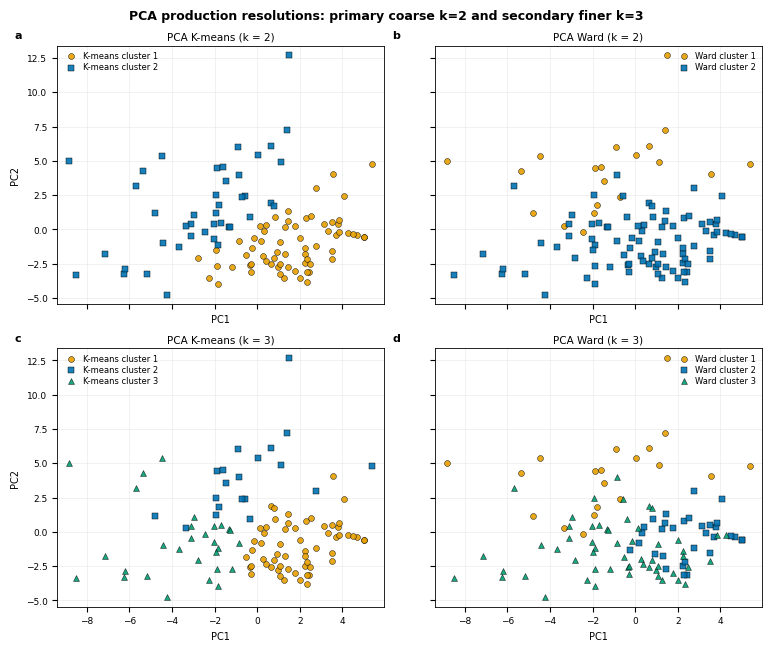

Displayed primary k=2 and secondary k=3 PCA projections; no manuscript figure was written.


In [10]:
# Notebook-only balanced display of both accepted resolutions; no model is refit.
figure_width_in = 7.6
figure_height_in = 6.4

plot_coordinates = pc_df.loc[:, ["PC1", "PC2"]]
assert plot_coordinates.shape == (108, 2), f"Expected 108 PC1/PC2 rows; got {plot_coordinates.shape}"
assert plot_coordinates["PC1"].equals(pc_df["PC1"])
assert plot_coordinates["PC2"].equals(pc_df["PC2"])
assert len(K2_PK) == len(K2_PH) == len(K3_PK) == len(K3_PH) == len(plot_coordinates) == 108
assert np.unique(K2_PK).size == np.unique(K2_PH).size == 2
assert np.unique(K3_PK).size == np.unique(K3_PH).size == 3
assert n_pcs_to_use == 12, "These projections document the finalized 12-PC clustering analysis."

x_pad = 0.04 * np.ptp(plot_coordinates["PC1"])
y_pad = 0.04 * np.ptp(plot_coordinates["PC2"])
shared_xlim = (plot_coordinates["PC1"].min() - x_pad, plot_coordinates["PC1"].max() + x_pad)
shared_ylim = (plot_coordinates["PC2"].min() - y_pad, plot_coordinates["PC2"].max() + y_pad)

publication_rc = {
    "font.size": 7, "axes.titlesize": 7.5, "axes.labelsize": 7,
    "xtick.labelsize": 6.5, "ytick.labelsize": 6.5, "legend.fontsize": 6,
    "axes.linewidth": 0.6, "grid.linewidth": 0.4, "figure.facecolor": "white",
    "axes.facecolor": "white", "savefig.facecolor": "white",
}
with plt.rc_context(publication_rc):
    fig, axes = plt.subplots(2, 2, figsize=(figure_width_in, figure_height_in),
                             sharex=True, sharey=True, constrained_layout=True)
    panel_specs = [
        (axes[0, 0], np.asarray(K2_PK), "PCA K-means (k = 2)", "K-means cluster", "a"),
        (axes[0, 1], np.asarray(K2_PH), "PCA Ward (k = 2)", "Ward cluster", "b"),
        (axes[1, 0], np.asarray(K3_PK), "PCA K-means (k = 3)", "K-means cluster", "c"),
        (axes[1, 1], np.asarray(K3_PH), "PCA Ward (k = 3)", "Ward cluster", "d"),
    ]
    for ax, labels, title, legend_prefix, panel_label in panel_specs:
        for label in np.unique(labels):
            mask = labels == label
            ax.scatter(plot_coordinates.loc[mask, "PC1"], plot_coordinates.loc[mask, "PC2"],
                       s=18, marker=cluster_marker_map[int(label)],
                       color=cluster_color_map[int(label)], edgecolor="black", linewidth=0.35,
                       alpha=0.9, label=f"{legend_prefix} {label}")
        ax.set_title(title, pad=4)
        ax.set_xlabel("PC1")
        ax.set_xlim(shared_xlim)
        ax.set_ylim(shared_ylim)
        ax.grid(True, color="0.88", alpha=0.8)
        ax.set_axisbelow(True)
        ax.legend(frameon=False, handletextpad=0.35, labelspacing=0.25, borderaxespad=0.3)
        ax.text(-0.13, 1.02, panel_label, transform=ax.transAxes, fontsize=8,
                fontweight="bold", va="bottom", ha="left")
    axes[0, 0].set_ylabel("PC2")
    axes[1, 0].set_ylabel("PC2")
    fig.suptitle("PCA production resolutions: primary coarse k=2 and secondary finer k=3",
                 fontsize=9, fontweight="bold")

    plt.show()

print("Displayed primary k=2 and secondary k=3 PCA projections; no manuscript figure was written.")